In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

In [4]:
import pandas as pd
import json

def load_jsonl(file_path):
    data = []
    with open("datasets/"+file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return pd.DataFrame(data)

In [5]:
# load each domain with label
finance = load_jsonl("finance.jsonl")
finance["source"] = "finance"

medicine = load_jsonl("medicine.jsonl")
medicine["source"] = "medicine"

eli5 = load_jsonl("reddit_eli5.jsonl")
eli5["source"] = "eli5"

wiki = load_jsonl("wiki_csai.jsonl")
wiki["source"] = "wiki"

openqa = load_jsonl("open_qa.jsonl")
openqa["source"] = "openqa"

In [14]:
# combine all domains into one dataframe
hc3_raw = pd.concat([finance, medicine, eli5, wiki, openqa], ignore_index=True)


print(hc3_raw.shape)
hc3_raw.head()

(24322, 5)


,question,human_answers,chatgpt_answers,source,index
0,Historical P/E ratios of small-cap vs. large-c...,[There is most likely an error in the WSJ's da...,[Historical price-to-earnings (P/E) ratios for...,finance,NaN
1,Should you co-sign a personal loan for a frien...,[I know this question has a lot of answers alr...,[Co-signing a personal loan for a friend or fa...,finance,NaN
2,Should I avoid credit card use to improve our ...,[If you pay it off before the cycle closes it ...,[It can be a good idea to avoid using credit c...,finance,NaN
3,Difference between 'split and redemption' of s...,[It is the first time I encounter redemption p...,[Share split and redemption are two different ...,finance,NaN
4,Pros & cons of investing in gold vs. platinum?,[Why Investors Buy Platinum is an old (1995) a...,[Gold and platinum are both precious metals th...,finance,NaN


In [16]:
# flatten
# human (label = 0)
human_df = hc3_raw[["human_answers", "source"]].explode("human_answers")
human_df = human_df.rename(columns={"human_answers": "text"})
human_df["label"] = 0

# AI (label = 1)
ai_df = hc3_raw[["chatgpt_answers", "source"]].explode("chatgpt_answers")
ai_df = ai_df.rename(columns={"chatgpt_answers": "text"})
ai_df["label"] = 1

# combine
hc3_df = pd.concat([human_df, ai_df], ignore_index=True)

In [17]:
print(hc3_df.shape)
hc3_df.head()

(85904, 3)


,text,source,label
0,There is most likely an error in the WSJ's dat...,finance,0
1,I know this question has a lot of answers alre...,finance,0
2,If you pay it off before the cycle closes it w...,finance,0
3,It is the first time I encounter redemption pr...,finance,0
4,Why Investors Buy Platinum is an old (1995) ar...,finance,0


In [18]:
# clean hc3 dataset
hc3_df = hc3_df.dropna(subset=["text"])
hc3_df["text"] = hc3_df["text"].astype(str).str.strip()

hc3_df = hc3_df[hc3_df["text"] != ""]
hc3_df = hc3_df.drop_duplicates(subset=["text", "label", "source"])

hc3_df["word_count"] = hc3_df["text"].str.split().str.len()
hc3_df = hc3_df[hc3_df["word_count"] >= 5].copy()

print(hc3_df.shape)
print(hc3_df["label"].value_counts())
print(hc3_df["source"].value_counts())

(79326, 4)
label
0    53079
1    26247
Name: count, dtype: int64
source
eli5        62087
finance      8391
openqa       4686
medicine     2549
wiki         1613
Name: count, dtype: int64


In [19]:
hc3_df.groupby("label")["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,53079.0,134.896626,164.918032,5.0,42.0,84.0,164.0,7904.0
1,26247.0,173.809388,60.820609,5.0,131.0,174.0,212.0,639.0


In [25]:
def run_svm_experiment(X_train_text, y_train, X_test_text, y_test, experiment_name):
    vectorizer = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9
    )
    
    X_train_tfidf = vectorizer.fit_transform(X_train_text)
    X_test_tfidf = vectorizer.transform(X_test_text)
    
    model = LinearSVC(class_weight="balanced", C=1.0, random_state=42)
    model.fit(X_train_tfidf, y_train)
    
    y_pred = model.predict(X_test_tfidf)
    
    print(f"\n===== {experiment_name} =====")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
    print("F1 score:", round(f1_score(y_test, y_pred), 4))
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))
    
    return {
        "experiment": experiment_name,
        "vectorizer": vectorizer,
        "model": model,
        "y_pred": y_pred
    }

In [26]:
# experiment A: 
X = hc3_df["text"]
y = hc3_df["label"]

X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

result_A = run_svm_experiment(
    X_train_A, y_train_A,
    X_test_A, y_test_A,
    "Experiment A: Random split on all HC3"
)


===== Experiment A: Random split on all HC3 =====
Accuracy: 0.9815
F1 score: 0.9722

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     10616
           1       0.97      0.98      0.97      5250

    accuracy                           0.98     15866
   macro avg       0.98      0.98      0.98     15866
weighted avg       0.98      0.98      0.98     15866

Confusion Matrix:

[[10436   180]
 [  114  5136]]


In [27]:
domains = hc3_df["source"].unique()
print(domains)

<StringArray>
['finance', 'medicine', 'eli5', 'wiki', 'openqa']
Length: 5, dtype: str


In [28]:
results = []

for domain in domains:
    print(f"\n===== HOLDOUT: {domain} =====")
    
    # split
    train_df = hc3_df[hc3_df["source"] != domain]
    test_df = hc3_df[hc3_df["source"] == domain]
    
    X_train = train_df["text"]
    y_train = train_df["label"]
    
    X_test = test_df["text"]
    y_test = test_df["label"]
    
    # vectorize
    vectorizer = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9
    )
    
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)
    
    # model
    model = LinearSVC(class_weight="balanced", C=1.0, random_state=42)
    model.fit(X_train_tfidf, y_train)
    
    # predict
    y_pred = model.predict(X_test_tfidf)
    
    # metrics
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # store results
    results.append({
        "held_out_domain": domain,
        "accuracy": acc,
        "f1_score": f1,
        "train_size": len(train_df),
        "test_size": len(test_df)
    })


===== HOLDOUT: finance =====
Accuracy: 0.9516
F1 Score: 0.9537

===== HOLDOUT: medicine =====
Accuracy: 0.9902
F1 Score: 0.9905

===== HOLDOUT: eli5 =====
Accuracy: 0.9170
F1 Score: 0.8252

===== HOLDOUT: wiki =====
Accuracy: 0.8308
F1 Score: 0.8571

===== HOLDOUT: openqa =====
Accuracy: 0.8094
F1 Score: 0.8582


In [29]:
results_df = pd.DataFrame(results)
results_df.sort_values(by="f1_score", ascending=False)

,held_out_domain,accuracy,f1_score,train_size,test_size
1,medicine,0.990192,0.990491,76777,2549
0,finance,0.951615,0.953685,70935,8391
4,openqa,0.809432,0.858231,74640,4686
3,wiki,0.830750,0.857143,77713,1613
2,eli5,0.917036,0.825171,17239,62087


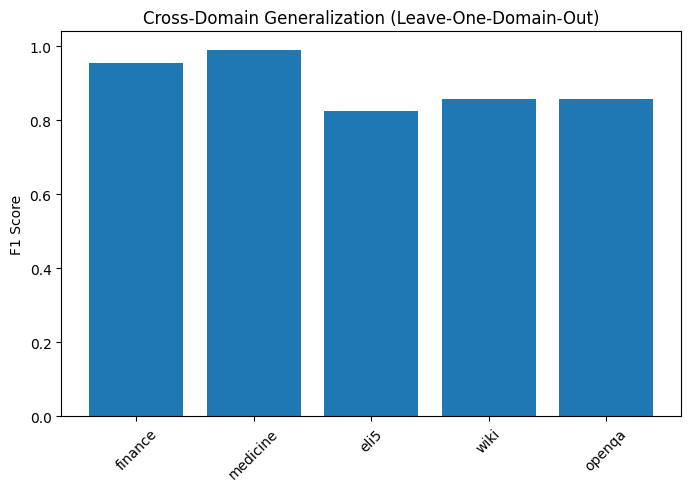

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_df["held_out_domain"], results_df["f1_score"])
plt.xticks(rotation=45)
plt.ylabel("F1 Score")
plt.title("Cross-Domain Generalization (Leave-One-Domain-Out)")
plt.show()

## Discussion:
We evaluate model performance using a leave-one-domain-out holdout strategy, where each domain is excluded from training and used solely for testing. This allows us to assess the model's ability to generalize to completely unseen domains.

The model achieves strong performance when structure domains such as medicine (F1≈0.99) and finance (F1≈0.95) are held out, indicating that these domains share common linguistic patterns with the training data. This suggests that the model is able to generalize effectively when the held-out domain is stylistically similar to those seen during training.

However, performance decreases for more general domains such as Wikipedia and open-domain QA (F1≈0.85), reflecting increased variability in language use and reduced alignment with training distributions.

The most significant drop is observed when Reddit ELI5 is held out (F1≈0.83), This domain differs substantially from others due to its informal, conversational style and simplified explanations. When ELI5 is excluded from training, the model struggles to distinguish between human and AI-generated text in this domain, suggesting that it relies heavily on stylistic cues that do not transfer well across domains.

Overall, the holdout results demontsrate that while the model generalizes well across similar domains, its performance degrades when applied to domains with distinct liguistic characteristics, highlighting limitations in cross-domain robustness.

In [33]:
amazon_df = pd.read_csv("datasets/amazon_review_dataset.csv")

In [34]:
amazon_df = amazon_df.dropna(subset=["raw_best_summary"]).copy()
amazon_df["text"] = amazon_df["raw_best_summary"].astype(str).str.strip()
amazon_df = amazon_df[amazon_df["text"] != ""].copy()

amazon_df["word_count"] = amazon_df["text"].str.split().str.len()
amazon_df = amazon_df[amazon_df["word_count"] >= 5].copy()

amazon_df = amazon_df.drop_duplicates(subset=["text"])

print(amazon_df.shape)
amazon_df[["text"]].head()

(4064, 28)


,text
0,WARNING: GRAPHIC CONTENT. CLICK HERE to read t...
1,Very bad experience with this device xr phone....
2,amazon.com: amazing phone with amazing camera ...
3,the face ID is not working and there's a glitc...
4,i've been an android user all my life until I ...


In [31]:
# experiment 3 - see how hc3-trained model behaves on real-world review text (Amazon review dataset)

vectorizer_C = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9
)

X_train_C = hc3_df["text"]
y_train_C = hc3_df["label"]

X_train_C_tfidf = vectorizer_C.fit_transform(X_train_C)

model_C = LinearSVC(class_weight="balanced", C=1.0, random_state=42)
model_C.fit(X_train_C_tfidf, y_train_C)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [35]:
X_amazon_tfidf = vectorizer_C.transform(amazon_df["text"])
amazon_pred = model_C.predict(X_amazon_tfidf)

amazon_df["predicted_label"] = amazon_pred
amazon_df["predicted_class"] = amazon_df["predicted_label"].map({0: "human", 1: "AI"})

amazon_df["predicted_class"].value_counts(normalize=True)

predicted_class
human    0.983514
AI       0.016486
Name: proportion, dtype: float64

In [36]:
summary = pd.DataFrame([
    {
        "experiment": "A: random HC3 split",
        "note": "standard in-domain evaluation"
    },
    {
        "experiment": "B: held-out HC3 domain",
        "note": "cross-domain evaluation within HC3"
    },
    {
        "experiment": "C: HC3 to Amazon",
        "note": "transfer to real-world review domain"
    }
])

summary

,experiment,note
0,A: random HC3 split,standard in-domain evaluation
1,B: held-out HC3 domain,cross-domain evaluation within HC3
2,C: HC3 to Amazon,transfer to real-world review domain


In [37]:
amazon_df["predicted_class"].value_counts()

predicted_class
human    3997
AI         67
Name: count, dtype: int64

In [38]:
amazon_df["predicted_class"].value_counts(normalize=True) * 100

predicted_class
human    98.351378
AI        1.648622
Name: proportion, dtype: float64

In [42]:
A_test_df = pd.DataFrame({
    "text": X_test_A.reset_index(drop=True),
    "true_label": y_test_A.reset_index(drop=True),
    "pred_label": result_A["y_pred"]
})

false_pos_A = A_test_df[(A_test_df["true_label"] == 0) & (A_test_df["pred_label"] == 1)]

false_pos_A.head(10)

,text,true_label,pred_label
292,"Interest rates are always given annually, to m...",0,1
303,"Let's break this into two parts, the future va...",0,1
334,Is eToro legitimate? If you have any doubts ab...,0,1
385,"It was released on November 15, 2001 in North ...",0,1
399,"Puff, the Magic Dragon is a song written by Le...",0,1
432,Pruning is a data compression technique in mac...,0,1
506,It may be because your washing and do n't have...,0,1
509,"In the past , you would often add bleach to wh...",0,1
627,Another reason can be bruxism . The nightly gr...,0,1
741,As a way to snub George W. Bush .,0,1


In [44]:
false_neg_A = A_test_df[(A_test_df["true_label"] == 1) & (A_test_df["pred_label"] == 0)]
false_neg_A.head(10)

,text,true_label,pred_label
4,"To do a moonwalk, you will need to start by st...",1,0
12,Transfer from credit to debi,1,0
26,"No, the subtraction of depreciation and amorti...",1,0
52,Reddit is a website where people can post thin...,1,0
211,"When you ""zip"" a file, you are basically takin...",1,0
223,Spiral arms in galaxies are formed by density ...,1,0
234,"In movies, actors and actresses often pretend ...",1,0
235,The SEC's EDGAR system displays a company's ea...,1,0
356,"When refinancing a condo in Wisconsin, you sho...",1,0
475,It's possible that there is an issue with the ...,1,0


In [45]:
amazon_df[amazon_df["predicted_label"] == 1][["text"]].head(20)

,text
252,first time user of iOS. Shifted from android t...
320,I received in original device sealed package. ...
360,overall device XR is far better than X and oth...
396,It's a great phone. Cut some stars as the came...
481,It’s always a charm to use device. Ease of use...
499,"Size is bit over, good battery life than previ..."
563,Good Priduct is a series of short films direct...
589,face recognition is very fast. Face recognitio...
731,device XR one of the best mobile and os . devi...
757,Only cons are overall little bezel around the ...


To further understand model behavior, we examine Amazon reviews that were incorrectly classified as AI-generated. These false positives reveal that the model relies heavvily on surface-level stylistic features rather than deeper semantic understanding.

Specifically, many misclassified reviews exhibit repetitive phrasing (e.g. repeated words or sentences), generic expressions (e.g., "overall satisfied"), or overly structured language. These characteristics resemble patterns commonly foudn in AI-generated text, leading the model to incorrectly classify them as synthetic.

Additionally, some misclassified samples contain noisy or poorly constructed sentences, which the model may associate with artificial generartion due to irregular linguistic patterns.

This analysis suggests that the model is sensitive to stylistic cues such as repetition and formality, rather than truly identifying the underlying origin of the text. As a result, it struggles to generalize to real-world data where such features can also appear in human-written content.

In [47]:
feature_names = vectorizer_C.get_feature_names_out()
coef = np.ravel(model_C.coef_)

top_human_idx = np.argsort(coef)[:20]
top_ai_idx = np.argsort(coef)[-20:]

print("Top human-indicative features:")
print([feature_names[i] for i in top_human_idx])

print("\nTop AI-indicative features:")
print([feature_names[i] for i in top_ai_idx])

Top human-indicative features:
['url_0', 'etc', 'basically', 'can not', 'thus', 'ca', 'only', 'do', 'most', 'pretty', 'edit', 'and or', 'does', 'stuff', 'but', 'all', 'mostly', 'then', 'either', 'wo']

Top AI-indicative features:
['means that', 'but it', 'other hand', 'doesn', 'nin', 'because they', 'even though', 'overall', 'helps to', 'and', 'sure', 'imagine you', 'important to', 'it important', 'was born', 'including', 'nthe', 'such as', 'does that', 'example if']
